# Customer Churn ML Model

Import files

In [1]:
# ........Install and Import all required libraries.....




In [2]:
# -------Import Libraries------

# --Core Libraries--
import pandas as pd
import numpy as np

# --Visualization Libraries--
import seaborn as sns
import matplotlib.pyplot as plt

# --ML Libraries
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE



# --- Display Setting
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)

print("All Libraries Loaded Successfully")

All Libraries Loaded Successfully


In [3]:
df = pd.read_excel('Customer Churn Dataset.xlsx')
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [4]:
df.shape

(7043, 21)

Dataset Information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Data Preprocessing

In [6]:
# Check missing Data

df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Column "TotalCharges" has 11 missing datapoints.

In [7]:
df[df['TotalCharges'].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [8]:
df.TotalCharges.dtype

dtype('float64')

In [9]:
df.TotalCharges.unique()

array([  29.85, 1889.5 ,  108.15, ...,  346.45,  306.6 , 6844.5 ],
      shape=(6531,))

<Axes: >

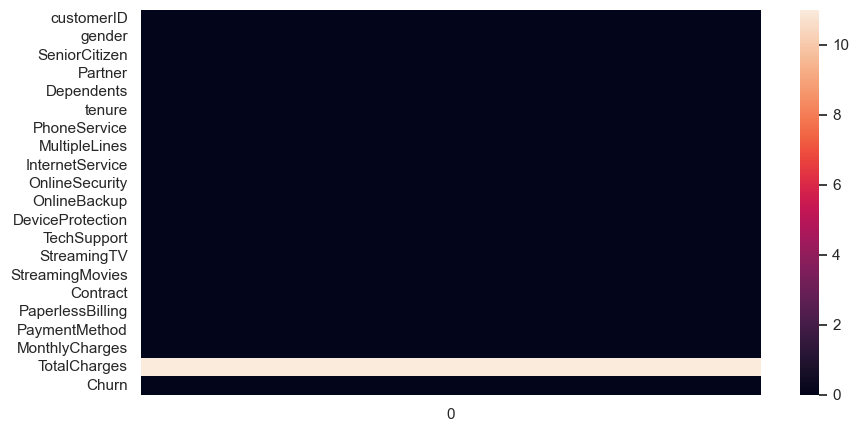

In [10]:
sns.heatmap(df.isnull().sum().to_frame())

In [11]:
# Filling the missing values

df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [12]:
# Checking the categorical variables

cat_cols = df.select_dtypes(include = ['object']).columns.tolist()
for col in cat_cols:
    print(f'{col:20s} > {df[col].unique().tolist()}')
    print()

customerID           > ['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU', '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU', '9763-GRSKD', '7469-LKBCI', '8091-TTVAX', '0280-XJGEX', '5129-JLPIS', '3655-SNQYZ', '8191-XWSZG', '9959-WOFKT', '4190-MFLUW', '4183-MYFRB', '8779-QRDMV', '1680-VDCWW', '1066-JKSGK', '3638-WEABW', '6322-HRPFA', '6865-JZNKO', '6467-CHFZW', '8665-UTDHZ', '5248-YGIJN', '8773-HHUOZ', '3841-NFECX', '4929-XIHVW', '6827-IEAUQ', '7310-EGVHZ', '3413-BMNZE', '6234-RAAPL', '6047-YHPVI', '6572-ADKRS', '5380-WJKOV', '8168-UQWWF', '8865-TNMNX', '9489-DEDVP', '9867-JCZSP', '4671-VJLCL', '4080-IIARD', '3714-NTNFO', '5948-UJZLF', '7760-OYPDY', '7639-LIAYI', '2954-PIBKO', '8012-SOUDQ', '9420-LOJKX', '6575-SUVOI', '7495-OOKFY', '4667-QONEA', '1658-BYGOY', '8769-KKTPH', '5067-XJQFU', '3957-SQXML', '5954-BDFSG', '0434-CSFON', '1215-FIGMP', '0526-SXDJP', '0557-ASKVU', '5698-BQJOH', '5122-CYFXA', '8627-ZYGSZ', '3410-YOQBQ', '3170-NMYVV', '7410-OIED

In [13]:
# Drop customer ID
df.drop('customerID', axis=1, inplace=True)

df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [14]:
# Convert 'No phone service' and "No internet service" to "No"
lst = ['No phone service', 'No internet service']

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].replace(lst, 'No')

# Map the target variable to binary values
binary_map = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}

binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 
               'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 
               'DeviceProtection', 'TechSupport', 'StreamingTV', 
               'StreamingMovies', 'PaperlessBilling']

for col in binary_cols:
    df[col] = df[col].map(binary_map)



In [15]:

# Convert categorical variables to dummy variables, One hot encoding 
df = pd.get_dummies(df, columns=['InternetService', 'Contract', 'PaymentMethod'], drop_first=False)




In [16]:

# convert the target variable to binary values
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})


print(f"New Shape of the dataset: {df.shape}")
print(f"\nChurn counts:\n{df['Churn'].value_counts()}")
print(f"\nSample of new columns:\n{df.columns.tolist()}")

New Shape of the dataset: (7043, 27)

Churn counts:
Churn
0    5174
1    1869
Name: count, dtype: int64

Sample of new columns:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [17]:
df.isnull().sum()

gender                                     0
SeniorCitizen                              0
Partner                                    0
Dependents                                 0
tenure                                     0
PhoneService                               0
MultipleLines                              0
OnlineSecurity                             0
OnlineBackup                               0
DeviceProtection                           0
TechSupport                                0
StreamingTV                                0
StreamingMovies                            0
PaperlessBilling                           0
MonthlyCharges                             0
TotalCharges                               0
Churn                                      0
InternetService_DSL                        0
InternetService_Fiber optic                0
InternetService_No                         0
Contract_Month-to-month                    0
Contract_One year                          0
Contract_T

In [18]:
df.head(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,0,0,0,1,29.85,29.85,0,True,False,False,True,False,False,False,False,True,False
1,1,0,0,0,34,1,0,1,0,1,0,0,0,0,56.95,1889.50,0,True,False,False,False,True,False,False,False,False,True
2,1,0,0,0,2,1,0,1,1,0,0,0,0,1,53.85,108.15,1,True,False,False,True,False,False,False,False,False,True
3,1,0,0,0,45,0,0,1,0,1,1,0,0,0,42.30,1840.75,0,True,False,False,False,True,False,True,False,False,False
4,0,0,0,0,2,1,0,0,0,0,0,0,0,1,70.70,151.65,1,False,True,False,True,False,False,False,False,True,False
5,0,0,0,0,8,1,1,0,0,1,0,1,1,1,99.65,820.50,1,False,True,False,True,False,False,False,False,True,False
6,1,0,0,1,22,1,1,0,1,0,0,1,0,1,89.10,1949.40,0,False,True,False,True,False,False,False,True,False,False
7,0,0,0,0,10,0,0,1,0,0,0,0,0,0,29.75,301.90,0,True,False,False,True,False,False,False,False,False,True
8,0,0,1,0,28,1,1,0,0,1,1,1,1,1,104.80,3046.05,1,False,True,False,True,False,False,False,False,True,False
9,1,0,0,1,62,1,0,1,1,0,0,0,0,0,56.15,3487.95,0,True,False,False,False,True,False,True,False,False,False


In [19]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
gender,7043.00,0.50,0.50,0.00,0.00,1.00,1.00,1.00
SeniorCitizen,7043.00,0.16,0.37,0.00,0.00,0.00,0.00,1.00
Partner,7043.00,0.48,0.50,0.00,0.00,0.00,1.00,1.00
Dependents,7043.00,0.30,0.46,0.00,0.00,0.00,1.00,1.00
tenure,7043.00,32.37,24.56,0.00,9.00,29.00,55.00,72.00
PhoneService,7043.00,0.90,0.30,0.00,1.00,1.00,1.00,1.00
MultipleLines,7043.00,0.42,0.49,0.00,0.00,0.00,1.00,1.00
OnlineSecurity,7043.00,0.29,0.45,0.00,0.00,0.00,1.00,1.00
OnlineBackup,7043.00,0.34,0.48,0.00,0.00,0.00,1.00,1.00
DeviceProtection,7043.00,0.34,0.48,0.00,0.00,0.00,1.00,1.00


Exploratory Data Analysis

Univariate, Bivariate and Multivariate Analysis

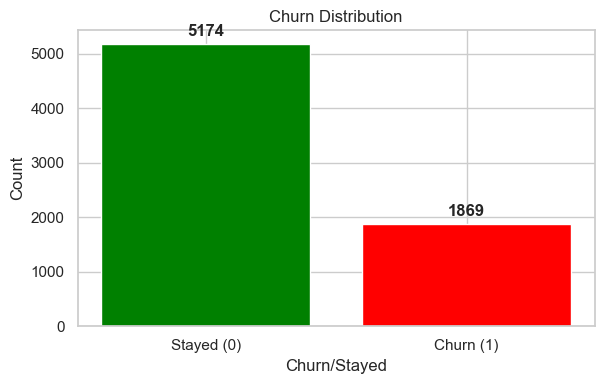

In [20]:
# Churn Distribution
# Determine how many customer churn, and how many customers do not churn. This will help us understand the distribution of the target variable and whether we have a class imbalance problem.

churn_counts = df['Churn'].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(['Stayed (0)', 'Churn (1)'],
         churn_counts.values, 
         color=['green', 'red'])

for i, count in enumerate(churn_counts.values):
    plt.text(i, count + 100, str(count), ha='center', va='bottom', fontweight='bold')
plt.title('Churn Distribution')
plt.xlabel('Churn/Stayed')
plt.tight_layout()
plt.ylabel('Count')
plt.show()

In [21]:
churn_percent = df['Churn'].value_counts()[1] / len(df['Churn']) * 100
print(f"Percentage of customers who churned: {churn_percent:.2f}%")
print(f"Percentage of customers who stayed: {100 - churn_percent:.2f}%")

Percentage of customers who churned: 26.54%
Percentage of customers who stayed: 73.46%


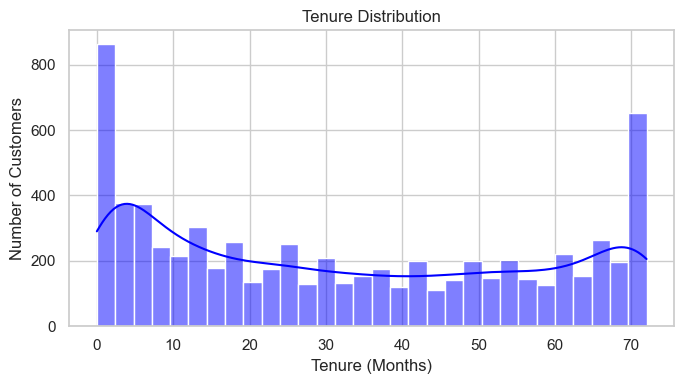

In [22]:
# Tenure distribution
plt.figure(figsize=(7, 4))
sns.histplot(data=df, x='tenure', bins=30, kde=True, color='blue')
plt.title('Tenure Distribution')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

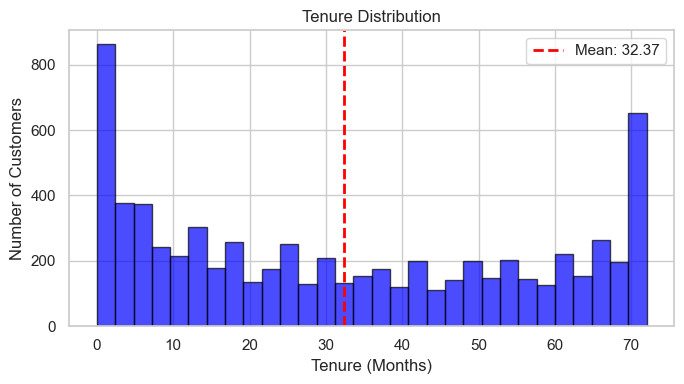

In [23]:
plt.figure(figsize=(7, 4))
plt.hist(df['tenure'], bins=30, color='blue', edgecolor='black', alpha=0.7)
plt.axvline(df['tenure'].mean(), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {df["tenure"].mean():.2f}')
plt.title('Tenure Distribution')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.legend()
plt.tight_layout()
plt.show()

Histogram plot of the tenure column depicts the period of patronage of the customers. 
It can be seen that about 800+ customers leave so quickly (spent 0-3months), less than 200 spent average months (32months)
While about 650 customers stayed upto 70-72 months.

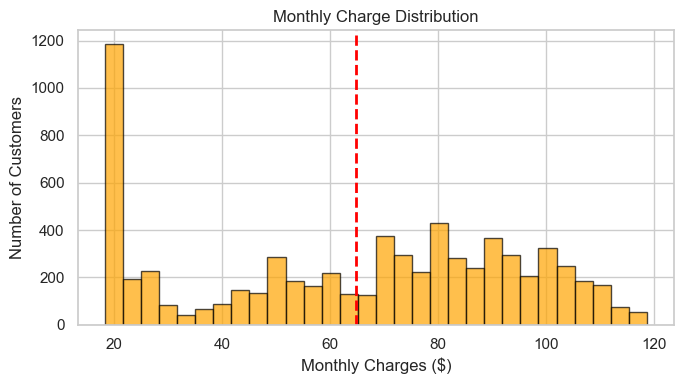

In [24]:
# Monthly charge distribution
plt.figure(figsize=(7, 4))
plt.hist(df['MonthlyCharges'], bins=30, color='orange', edgecolor='black', alpha=0.7)
plt.axvline(df['MonthlyCharges'].mean(), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {df["MonthlyCharges"].mean():.2f}')
plt.title('Monthly Charge Distribution')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

Customers on cheaper monthly plans are more than those on costly monthly plans.

<Axes: ylabel='MonthlyCharges'>

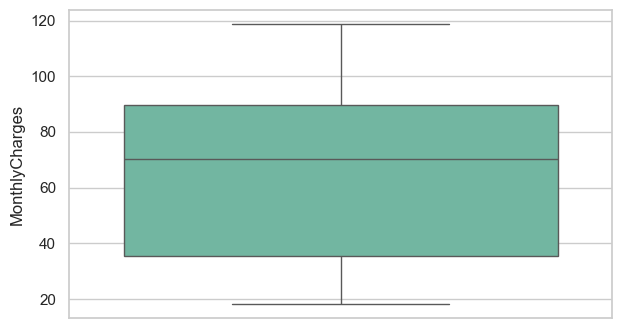

In [25]:
plt.figure(figsize=(7,4))
sns.boxplot(df['MonthlyCharges'])


<Axes: ylabel='tenure'>

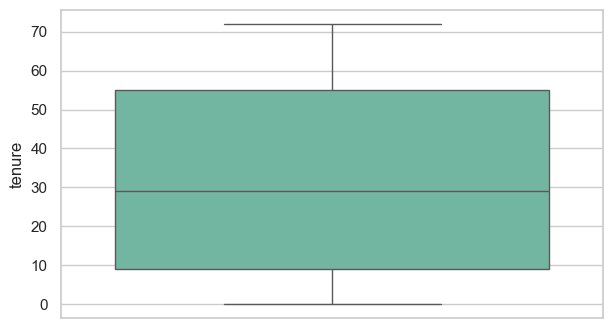

In [26]:
plt.figure(figsize=(7,4))
sns.boxplot(df['tenure'])


TOtal Charges
Lowest: $0.00
Average: $2279.73
Highest: $8684.80


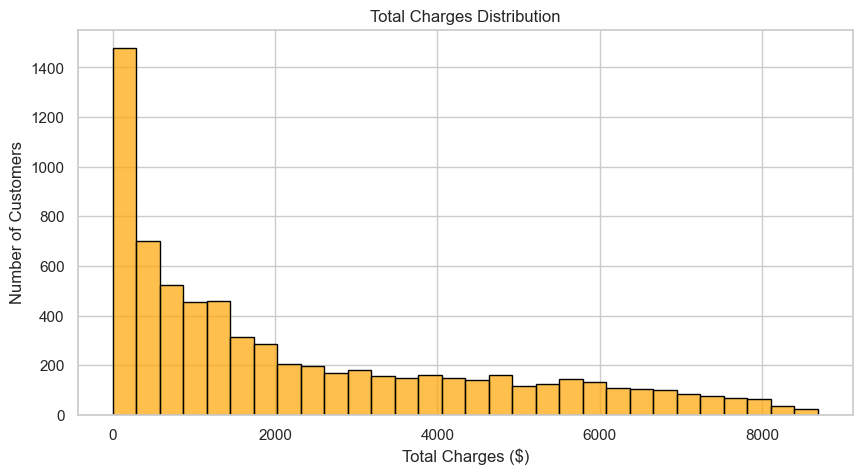

In [27]:
# Distribution of total Charge
sns.histplot(df['TotalCharges'], bins=30, color='orange', edgecolor='black', alpha=0.7)
plt.title('Total Charges Distribution')
plt.xlabel('Total Charges ($)')
plt.ylabel('Number of Customers')

print('TOtal Charges')
print(f'Lowest: ${df['TotalCharges'].min():.2f}')
print(f'Average: ${df['TotalCharges'].mean():.2f}')
print(f'Highest: ${df['TotalCharges'].max():.2f}')

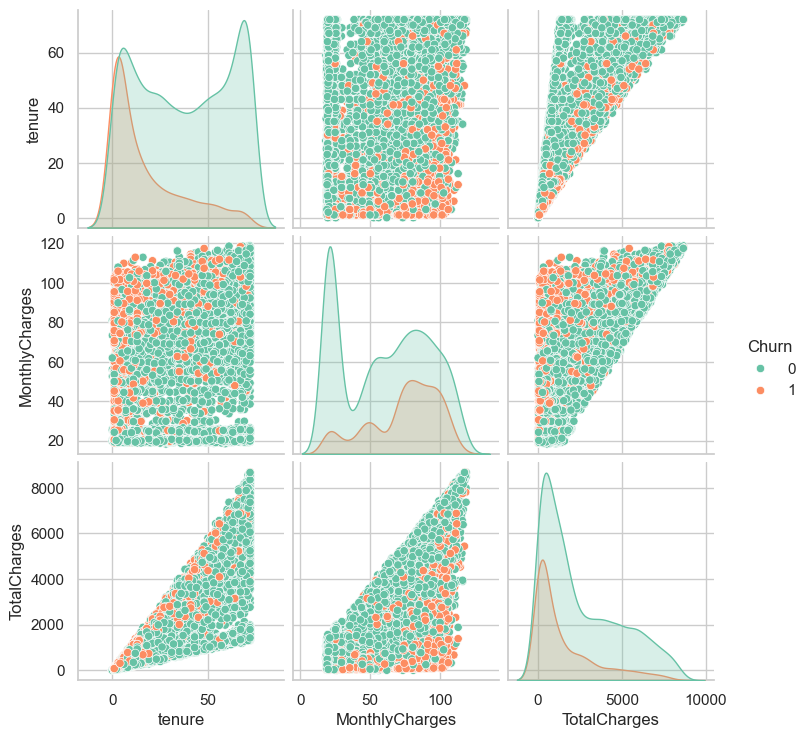

In [28]:
sns.pairplot(df, hue='Churn', vars=['tenure', 'MonthlyCharges', 'TotalCharges'], palette='Set2')
plt.show()

BIVARIATE ANALYSIS

<Figure size 700x400 with 0 Axes>

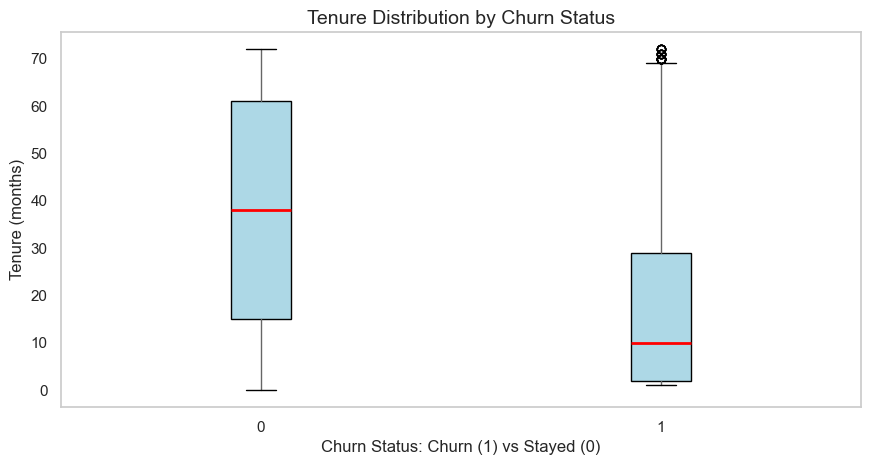

Average tenure by Churn Status:
Churn
0   37.60
1   18.00
Name: tenure, dtype: float64


In [29]:
# Do churner's leave early?
# How long do churners spent before they leave?
# We are answering this question using a boxplot to visualize the relationship between Tenure and Churn. 
# The boxplot will show the distribution of tenure for customers who churned and those who did not churn. 
# This will help us understand if there is a significant difference in tenure between the two groups.

plt.figure(figsize=(7, 4))
df.boxplot(column='tenure', by='Churn', grid=False, 
           patch_artist=True, boxprops=dict(facecolor='lightblue', color='black'),
           medianprops=dict(color='red', linewidth=2))

plt.title('Tenure Distribution by Churn Status', fontsize=14)
plt.suptitle('') # Remove the default title
plt.xlabel('Churn Status: Churn (1) vs Stayed (0)')
plt.ylabel('Tenure (months)')
plt.show()

#Metrics for Tenure by Churn Status
print("Average tenure by Churn Status:")
print(df.groupby('Churn')['tenure'].mean().round(1))

<Figure size 700x400 with 0 Axes>

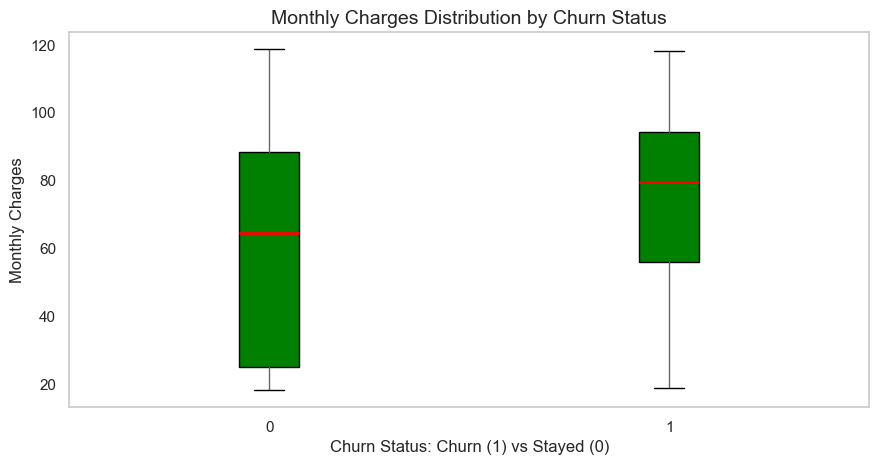

Average monthly charges by Churn Status:
Churn
0   61.30
1   74.40
Name: MonthlyCharges, dtype: float64


In [30]:
# Do customers who pay more churn more?

plt.figure(figsize=(7, 4))
df.boxplot(column='MonthlyCharges', by='Churn', grid=False, 
           patch_artist=True, boxprops=dict(facecolor='green', color='black'),
           medianprops=dict(color='red', linewidth=2))

plt.title('Monthly Charges Distribution by Churn Status', fontsize=14)
plt.suptitle('') # Remove the default title
plt.xlabel('Churn Status: Churn (1) vs Stayed (0)')
plt.ylabel('Monthly Charges')
plt.show()

#Metrics for Monthly Charges by Churn Status
print("Average monthly charges by Churn Status:")
print(df.groupby('Churn')['MonthlyCharges'].mean().round(1))

The boxplot shows that most people who left are high paying customers.

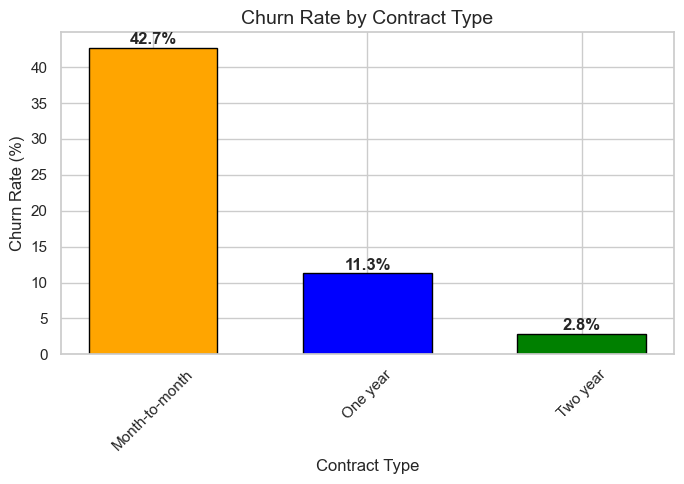

Churn Rate by Contract Type:
Contract_Type
Month-to-month   42.70
One year         11.30
Two year          2.80
Name: Churn, dtype: float64


In [31]:
# contrac type vs churn

contract_churn = df.groupby(['Contract_Month-to-month',
                             'Contract_One year', 
                             'Contract_Two year'])['Churn'].mean()*100

# Better approach

df['Contract_Type']='Month-to-month'
df.loc[df['Contract_One year'] == 1, 'Contract_Type'] = 'One year'
df.loc[df['Contract_Two year'] == 1, 'Contract_Type'] = 'Two year'

churn_by_contract = df.groupby('Contract_Type')['Churn'].mean()*100

plt.figure(figsize=(7, 5))
bars = plt.bar(churn_by_contract.index, churn_by_contract.values,
                color=['orange', 'blue', 'green'],
                edgecolor = 'black', width=0.6)

#Percentage labels on top of the bars
for bar, val in zip(bars, churn_by_contract.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontweight='bold')

plt.title('Churn Rate by Contract Type', fontsize=14)
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Churn Rate by Contract Type:")
print(churn_by_contract.round(1))

In [32]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'InternetService_DSL', 'InternetService_Fiber optic',
       'InternetService_No', 'Contract_Month-to-month', 'Contract_One year',
       'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'Contract_Type'],
      dtype='object')

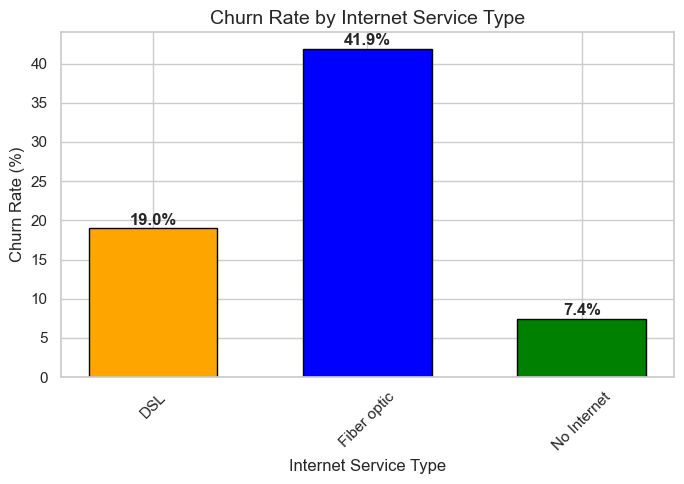

Churn Rate by Internet Service:
Internet_Type
DSL           19.00
Fiber optic   41.90
No Internet    7.40
Name: Churn, dtype: float64


In [33]:

# Grphical representation of churn rate by internet service type

df['Internet_Type']='No Internet'
df.loc[df['InternetService_DSL'] == 1, 'Internet_Type'] = 'DSL'
df.loc[df['InternetService_Fiber optic'] == 1, 'Internet_Type'] = 'Fiber optic'


churn_by_internet = df.groupby('Internet_Type')['Churn'].mean()*100

plt.figure(figsize=(7, 5))
bars = plt.bar(churn_by_internet.index, churn_by_internet.values,
                color=['orange', 'blue', 'green'],
                edgecolor = 'black', width=0.6)

for bar, val in zip(bars, churn_by_internet.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontweight='bold')

plt.title('Churn Rate by Internet Service Type', fontsize=14)
plt.xlabel('Internet Service Type')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


print("Churn Rate by Internet Service:")
print(churn_by_internet.round(1))


From the analysis of Churn rate by Internet service type, it means, those on Fibre Optics leaves more than those on other service type. Also, the initial analysis shows that those on high service plans churn than every other plan subscribers. 
WHile Fibre optics is costlier than every other internet service, it can be deduce that those on Fibre Type churn due to high service charge rate.

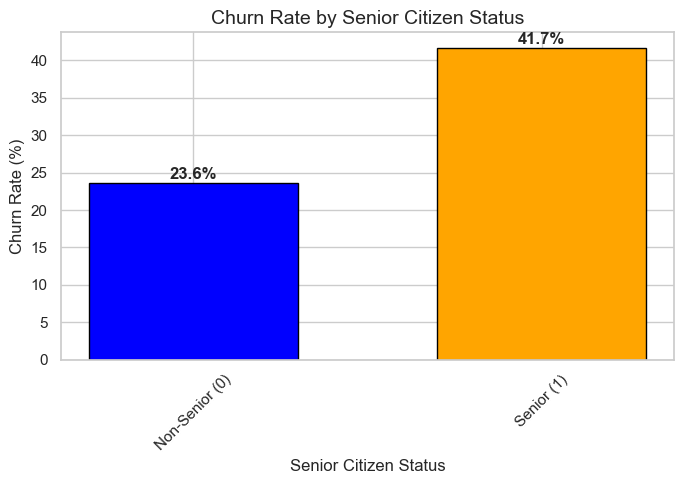

Churn Rate by Senior Citizen Status:
SeniorCitizen
0   23.60
1   41.70
Name: Churn, dtype: float64

Customer Count by Senior Citizen Status:
SeniorCitizen
0    5901
1    1142
dtype: int64


In [34]:
# Senior Citizen

churn_by_senior = df.groupby('SeniorCitizen')['Churn'].mean()*100

plt.figure(figsize=(7, 5))
bars = plt.bar(['Non-Senior (0)', 'Senior (1)'],
                churn_by_senior.values,
                color=['blue', 'orange'],
                edgecolor='black', width=0.6)

for bar, val in zip(bars, churn_by_senior.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontweight='bold')

plt.title('Churn Rate by Senior Citizen Status', fontsize=14)
plt.xlabel('Senior Citizen Status')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Churn Rate by Senior Citizen Status:")
print(churn_by_senior.round(1))

print("\nCustomer Count by Senior Citizen Status:")
print(df.groupby('SeniorCitizen').size())



In [35]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'InternetService_DSL', 'InternetService_Fiber optic',
       'InternetService_No', 'Contract_Month-to-month', 'Contract_One year',
       'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'Contract_Type', 'Internet_Type'],
      dtype='object')

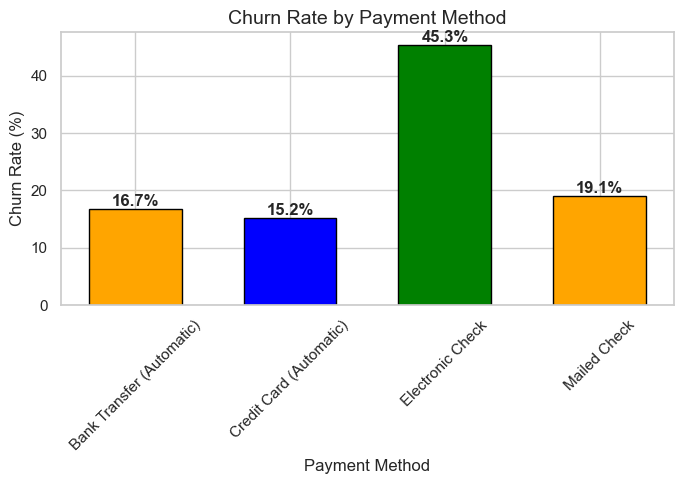

Churn Rate by Payment Method:
Payment_Method
Bank Transfer (Automatic)   16.70
Credit Card (Automatic)     15.20
Electronic Check            45.30
Mailed Check                19.10
Name: Churn, dtype: float64


In [36]:
# Churn by Payment Method


df['Payment_Method'] = 'Bank Transfer (Automatic)'
df.loc[df['PaymentMethod_Credit card (automatic)'] == 1, 'Payment_Method'] = 'Credit Card (Automatic)'
df.loc[df['PaymentMethod_Electronic check'] == 1, 'Payment_Method'] = 'Electronic Check'
df.loc[df['PaymentMethod_Mailed check'] == 1, 'Payment_Method'] = 'Mailed Check'


churn_by_payment_method = df.groupby('Payment_Method')['Churn'].mean()*100

plt.figure(figsize=(7, 5))
bars = plt.bar(churn_by_payment_method.index, churn_by_payment_method.values,
                color=['orange', 'blue', 'green'],
                edgecolor = 'black', width=0.6)

for bar, val in zip(bars, churn_by_payment_method.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontweight='bold')

plt.title('Churn Rate by Payment Method', fontsize=14)
plt.xlabel('Payment Method')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Churn Rate by Payment Method:")
print(churn_by_payment_method.round(1))


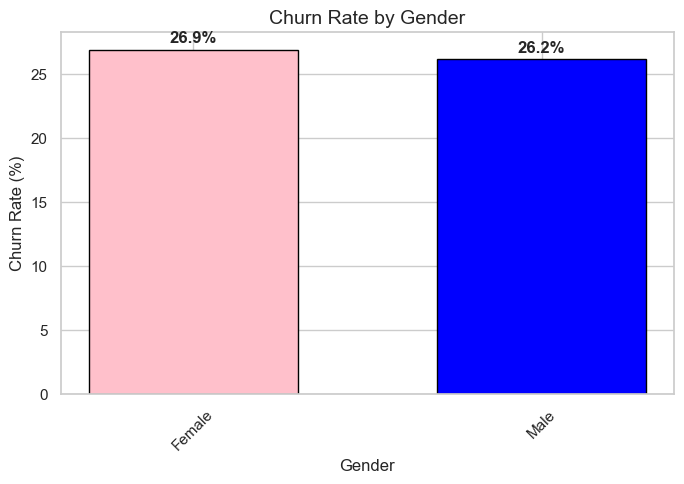

Churn Rate by Gender:
gender
0   26.90
1   26.20
Name: Churn, dtype: float64

Customer Count by Gender:
gender
0    3488
1    3555
dtype: int64


In [37]:
# Churn rate by Gender


churn_by_Gender = df.groupby('gender')['Churn'].mean()*100

plt.figure(figsize=(7, 5))
bars = plt.bar(['Female', 'Male'],
                churn_by_Gender.values,
                color=['pink', 'blue'],
                edgecolor='black', width=0.6)

for bar, val in zip(bars, churn_by_Gender.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontweight='bold')

plt.title('Churn Rate by Gender', fontsize=14)
plt.xlabel('Gender')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Churn Rate by Gender:")
print(churn_by_Gender.round(1))

print("\nCustomer Count by Gender:")
print(df.groupby('gender').size())





Both gender churn at the same rate. It mmeans that gender column has no contribution in our prediction task.

## MULTIVARIATE ANALYSIS

In [38]:
# drop temporary columns used for visualization
df_corr=df.drop(['Contract_Type', 'Internet_Type', 'Payment_Method'], axis=1, inplace=False)


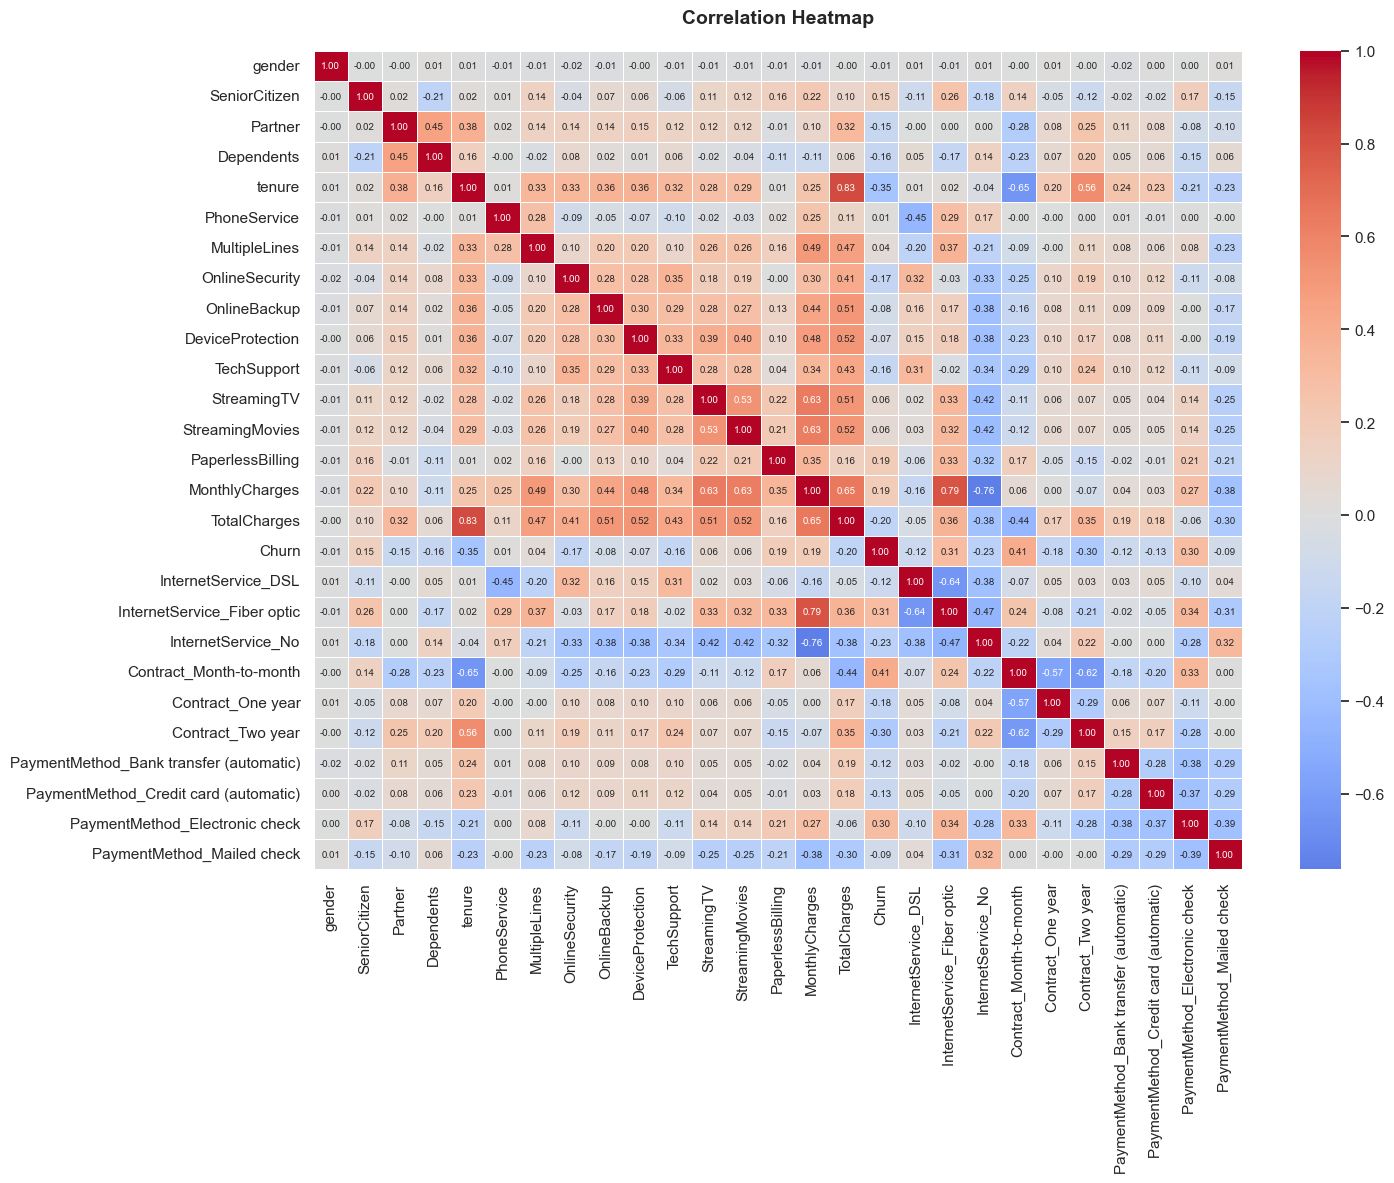

In [39]:

plt.figure(figsize=(15, 12))
sns.heatmap(df_corr.corr(), 
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            linewidths=0.5,
            annot_kws={'size': 7})

plt.title('Correlation Heatmap', 
          fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

In [40]:

print("Correlation with Churn:")
print(df_corr.corr()['Churn'].sort_values(ascending=False).round(2))

Correlation with Churn:
Churn                                      1.00
Contract_Month-to-month                    0.41
InternetService_Fiber optic                0.31
PaymentMethod_Electronic check             0.30
MonthlyCharges                             0.19
PaperlessBilling                           0.19
SeniorCitizen                              0.15
StreamingTV                                0.06
StreamingMovies                            0.06
MultipleLines                              0.04
PhoneService                               0.01
gender                                    -0.01
DeviceProtection                          -0.07
OnlineBackup                              -0.08
PaymentMethod_Mailed check                -0.09
PaymentMethod_Bank transfer (automatic)   -0.12
InternetService_DSL                       -0.12
PaymentMethod_Credit card (automatic)     -0.13
Partner                                   -0.15
Dependents                                -0.16
TechSupport     

FEATURE ENGINEERING

In [41]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Contract_Type,Internet_Type,Payment_Method
0,0,0,1,0,1,0,0,0,1,0,0,0,0,1,29.85,29.85,0,True,False,False,True,False,False,False,False,True,False,Month-to-month,DSL,Electronic Check
1,1,0,0,0,34,1,0,1,0,1,0,0,0,0,56.95,1889.50,0,True,False,False,False,True,False,False,False,False,True,One year,DSL,Mailed Check
2,1,0,0,0,2,1,0,1,1,0,0,0,0,1,53.85,108.15,1,True,False,False,True,False,False,False,False,False,True,Month-to-month,DSL,Mailed Check
3,1,0,0,0,45,0,0,1,0,1,1,0,0,0,42.30,1840.75,0,True,False,False,False,True,False,True,False,False,False,One year,DSL,Bank Transfer (Automatic)
4,0,0,0,0,2,1,0,0,0,0,0,0,0,1,70.70,151.65,1,False,True,False,True,False,False,False,False,True,False,Month-to-month,Fiber optic,Electronic Check


In [42]:
# Create Vertical split
# Create x and y variables for model training

# Feature variables
x = df.drop(['Churn',
             'Contract_Type',
             'Internet_Type',
             'Payment_Method'
             ], axis=1, errors='ignore')

# Target variable
y = df['Churn']


In [43]:
print(f"Shape of x: {x.shape}")
print(f"Shape of y: {y.shape}")
print(f"Sample of x columns:\n{x.columns.tolist()}")
for col in x.columns:
    print(f"{col:20s} > {x[col].dtype}")

print(f"Target Distribution:\n{y.value_counts()}")

Shape of x: (7043, 26)
Shape of y: (7043,)
Sample of x columns:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']
gender               > int64
SeniorCitizen        > int64
Partner              > int64
Dependents           > int64
tenure               > int64
PhoneService         > int64
MultipleLines        > int64
OnlineSecurity       > int64
OnlineBackup         > int64
DeviceProtection     > int64
TechSupport          > int64
StreamingTV          > int64
StreamingMovies      > int64
PaperlessBill

Training - Testing Split


In [44]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

print(f"Split Complete")
print(f"\nTraining Set: {x_train.shape[0]} Customers(80% of total)")
print(f"Test Set: {x_test.shape[0]} Customers(20% of total)")
print(f"\nChurn rate in Training Set: {y_train.mean()*100:.2f}%")
print(f"Churn rate in Test Set: {y_test.mean()*100:.2f}%")

Split Complete

Training Set: 5634 Customers(80% of total)
Test Set: 1409 Customers(20% of total)

Churn rate in Training Set: 26.54%
Churn rate in Test Set: 26.54%


Training XGBClassifier ALgorithm

In [45]:
xgbc = XGBClassifier(random_state=42, eval_metric='logloss')
xgbc.fit(x_train, y_train)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [46]:
# PRedict on the test set
y_pred = xgbc.predict(x_test)

In [47]:
# Evaluation Metrics, using classification report and confusion matrix, roc_auc_score, and confusion matrix display

class_report = classification_report(y_test, y_pred, target_names=['Stayed (0)', 'Churn (1)'])
conf_matrix = confusion_matrix(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)


print(f"Classification Report: ")
print(class_report)
print(f"ROC-AUC: {roc_auc:.4f}")

Classification Report: 
              precision    recall  f1-score   support

  Stayed (0)       0.83      0.89      0.86      1035
   Churn (1)       0.61      0.50      0.55       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.78      1409

ROC-AUC: 0.6925


Standardscaling
scaling numeric columns

In [48]:
scaler = StandardScaler()

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
x_train[numeric_cols] = scaler.fit_transform(x_train[numeric_cols])
x_test[numeric_cols] = scaler.transform(x_test[numeric_cols])

print(x_train[numeric_cols].describe().round(2))

       tenure  MonthlyCharges  TotalCharges
count 5634.00         5634.00       5634.00
mean    -0.00           -0.00          0.00
std      1.00            1.00          1.00
min     -1.32           -1.54         -1.01
25%     -0.96           -0.97         -0.83
50%     -0.14            0.18         -0.40
75%      0.92            0.83          0.67
max      1.61            1.79          2.80


In [49]:
# Apply SMOTE to balance the classes in the training set
smote = SMOTE(random_state=42)

x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

print(f"Before SMOTE, Training Set: {x_train.shape[0]} Customers")
print(f"Before SMOTE, Training Set (Churn): {y_train.sum()} Customers")

print(f"After SMOTE, Training Set: {x_train_smote.shape[0]} Customers")
print(f"After SMOTE, Training Set (Churn): {y_train_smote.sum()} Customers")


Before SMOTE, Training Set: 5634 Customers
Before SMOTE, Training Set (Churn): 1495 Customers
After SMOTE, Training Set: 8278 Customers
After SMOTE, Training Set (Churn): 4139 Customers


In [50]:
print(f"Before Smote, No of Churn customers: {y_train.sum()}/{x_train.shape[0]} ({y_train.mean()*100:.2f}%)")
print(f"After Smote, No of Churn customers: {y_train_smote.sum()}/{x_train_smote.shape[0]} ({y_train_smote.mean()*100:.2f}%)")

Before Smote, No of Churn customers: 1495/5634 (26.54%)
After Smote, No of Churn customers: 4139/8278 (50.00%)


ML-DEVELOPMENT PHASE

In [51]:
# Logistic Regression Model

#Build and train the logistic regression model on the balanced training set
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(x_train_smote, y_train_smote)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [52]:
# Predict on the test set using the logistic regression model
y_pred_lr = lr_model.predict(x_test)
lr_proba = lr_model.predict_log_proba(x_test)[:, 1]

In [53]:
# Evaluation 
print("=" * 50)
print(" MODEL 1: LOGISTIC REGRESSION RESULTS")
print("=" * 50)

print("Classification Report:")
print(classification_report(y_test, y_pred_lr, 
                            target_names=['No Churn (0)', 'Churn (1)']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, lr_proba):.4f}")

 MODEL 1: LOGISTIC REGRESSION RESULTS
Classification Report:
              precision    recall  f1-score   support

No Churn (0)       0.89      0.77      0.83      1035
   Churn (1)       0.54      0.72      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.76      0.77      1409

ROC-AUC Score: 0.8356


In [54]:
# RANDOM FOREST CLASSIFIER
from sklearn.ensemble import RandomForestClassifier


rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(x_train_smote, y_train_smote)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [55]:
# Make predictions on the test set using the random forest model
y_pred_rf = rf_model.predict(x_test)
rf_proba = rf_model.predict_proba(x_test)[:, 1]


In [56]:
# Evaluate the model performance using classification report and confusion matrix
 
print("=" * 50)
print(" MODEL 2: RANDOM FOREST RESULTS")
print("=" * 50)

print("Classification Report:")
print(classification_report(y_test, y_pred_rf, 
                            target_names=['No Churn (0)', 'Churn (1)']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, rf_proba):.4f}")

 MODEL 2: RANDOM FOREST RESULTS
Classification Report:
              precision    recall  f1-score   support

No Churn (0)       0.86      0.82      0.84      1035
   Churn (1)       0.56      0.63      0.60       374

    accuracy                           0.77      1409
   macro avg       0.71      0.73      0.72      1409
weighted avg       0.78      0.77      0.78      1409

ROC-AUC Score: 0.8220


In [57]:
# XGBoost Classifier
xgb_c = XGBClassifier()
xgb_c.fit(x_train_smote, y_train_smote)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [58]:
# Prediction
y_pred_xgb = xgb_c.predict(x_test)
xgb_proba = xgb_c.predict_proba(x_test)[:, 1]

print("=" * 50)
print(" MODEL 3: XGBOOST RESULTS")
print("=" * 50)

print("Classification Report:")
print(classification_report(y_test, y_pred_xgb, 
                            target_names=['No Churn (0)', 'Churn (1)']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_xgb):.4f}")

 MODEL 3: XGBOOST RESULTS
Classification Report:
              precision    recall  f1-score   support

No Churn (0)       0.87      0.80      0.84      1035
   Churn (1)       0.55      0.68      0.61       374

    accuracy                           0.77      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.77      0.78      1409

ROC-AUC Score: 0.7409


MODEL EVALUATION AND VISUALIZATION

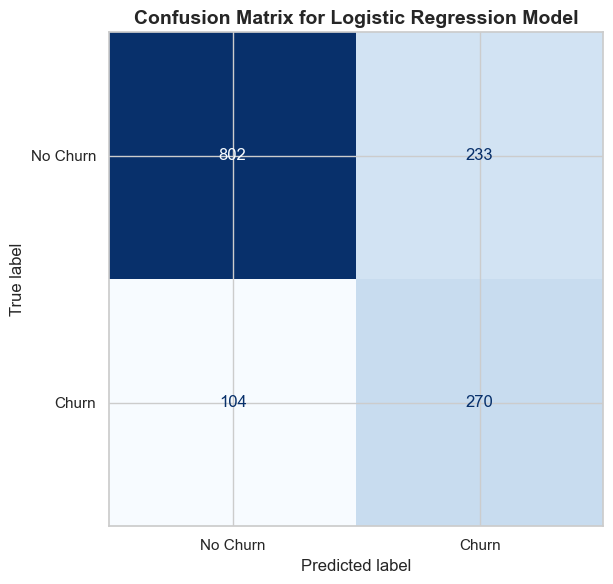

True Negatives (Correctly predicted no churn: Stay): 802
False Positives: (Wrongly predicted churn) 233
False Negatives: (Wrongly predicted no churn) 104
True Positives: (Correctly predicted churn) 270

Accuracy: 0.7608


In [61]:
# CONFUSION MATRIX PLOT FOR LOGISTIC REGRESSION MODEL

cmlr = confusion_matrix(y_test, y_pred_lr)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cmlr, 
                              display_labels=['No Churn', 'Churn'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix for Logistic Regression Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Breakdown
tn, fp, fn, tp = cmlr.ravel()
print(f"True Negatives (Correctly predicted no churn: Stay): {tn}")
print(f"False Positives: (Wrongly predicted churn) {fp}")
print(f"False Negatives: (Wrongly predicted no churn) {fn}")
print(f"True Positives: (Correctly predicted churn) {tp}")

print(f"\nAccuracy: {(tn + tp) / (tn + fp + fn + tp):.4f}")

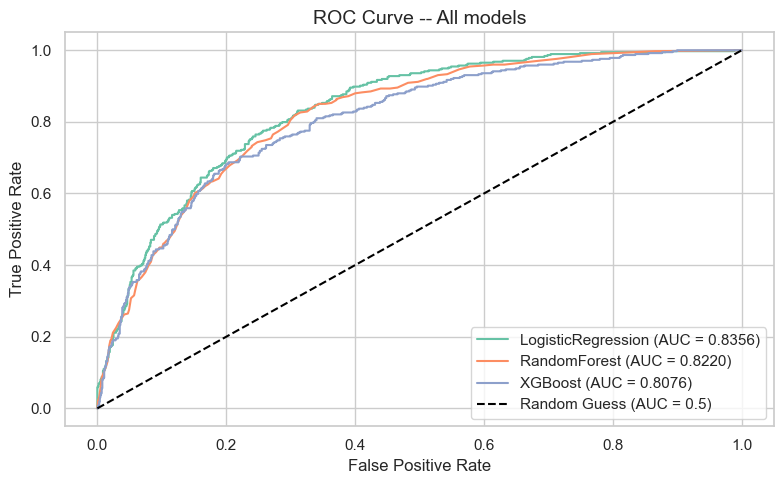

AUC SCore
Logistic Regression : 0.8356
Random Forest : 0.8220
XGBoost : 0.8076


In [62]:
# ROC-AUC Curve of all 3-models
plt.figure(figsize=(8,5))

for name, proba in [('LogisticRegression', lr_proba),
                    ('RandomForest', rf_proba), 
                    ('XGBoost', xgb_proba)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})')

# Random guess baseline

plt.plot([0,1], [0,1], 'k--', label='Random Guess (AUC = 0.5)')

plt.title('ROC Curve -- All models', fontsize=14)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

#AUC Scores

print("AUC SCore")
print(f"Logistic Regression : {roc_auc_score(y_test, lr_proba):.4f}")
print(f"Random Forest : {roc_auc_score(y_test, rf_proba):.4f}")
print(f"XGBoost : {roc_auc_score(y_test, xgb_proba):.4f}")

Feature Importance

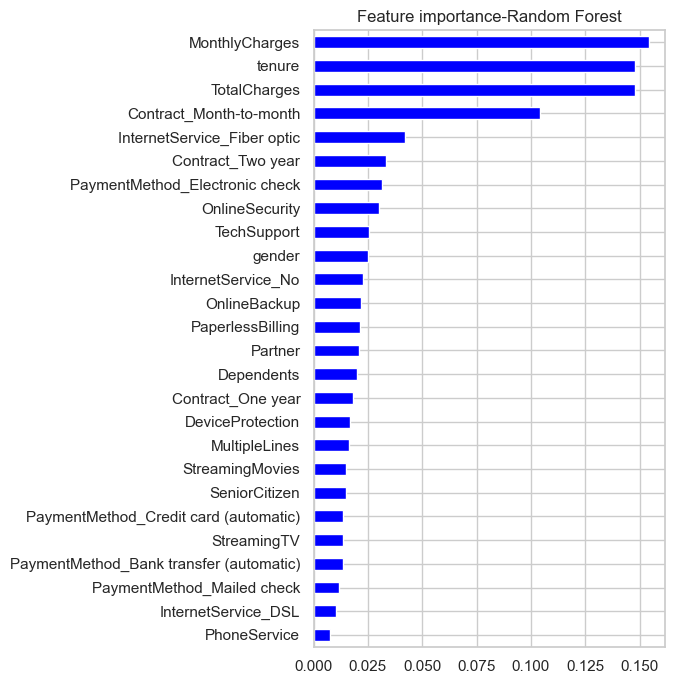

Top 5 Most Important Features
MonthlyCharges                0.15
tenure                        0.15
TotalCharges                  0.15
Contract_Month-to-month       0.10
InternetService_Fiber optic   0.04
dtype: float64


In [64]:
importance = pd.Series(rf_model.feature_importances_, 
                       index=x.columns)
importance = importance.sort_values(ascending=True)

plt.figure(figsize=(7,7))
importance.plot(kind='barh', color='Blue')
plt.title('Feature importance-Random Forest')
plt.tight_layout()
plt.show()

print("Top 5 Most Important Features")
print(importance.sort_values(ascending=False).head())

Final model comparison

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, roc_auc_score, precision_score

# collect all scores

models = ['Logistic Regression', 'Random Forest', 'XGBoost']
metrics = {
    'Accuracy': [accuracy_score(y_test, y_pred_lr),
                 accuracy_score(y_test, y_pred_rf),
                 accuracy_score(y_test, y_pred_xgb)],

    'Precision': [precision_score(y_test, y_pred_lr),
                 precision_score(y_test, y_pred_rf),
                 precision_score(y_test, y_pred_xgb)],

    'Recall':   [recall_score(y_test, y_pred_lr),
                 recall_score(y_test, y_pred_rf),
                 recall_score(y_test, y_pred_xgb)],

    'F1_score':  [f1_score(y_test, y_pred_lr),
                 f1_score(y_test, y_pred_rf),
                 f1_score(y_test, y_pred_xgb)],
    'ROC-AUC':   [roc_auc_score(y_test, lr_proba),
                 roc_auc_score(y_test, rf_proba),
                 roc_auc_score(y_test, xgb_proba)]}

result_df = pd.DataFrame(metrics, index=models)

# plot
result_df.plot(kind='bar', figsize=(12,6),
               edgecolor='black', width=0.7)

plt.title('Final Model COmparison', fontsize=14,
          fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


SyntaxError: invalid syntax (2433692938.py, line 7)

DEPLOYMENT

In [59]:
import joblib

In [60]:
joblib.dump(xgb_c 'churnmodel.pkl')
joblib.dump(scaler, 'churn_scaler.pkl')
joblib.dump(x.columns, 'feature_columns.pkl')

SyntaxError: invalid syntax (149567234.py, line 1)